## Importing the Library

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score,confusion_matrix
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import GlobalAveragePooling2D,Input, BatchNormalization, Dense,Dropout, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Flatten
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model,load_model
import seaborn as sns
import gc

2025-07-30 04:22:49.514354: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753849369.736344      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753849369.797682      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Loading the Model

In [2]:
model_path = '/kaggle/input/screen-detector/tensorflow2/default/1/screen_detector.h5'
model = load_model(model_path)

I0000 00:00:1753849384.029731      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


## Dataset generator

In [3]:
def build_dataset_from_direct_paths(path_real, path_fake, img_size=(224, 224)):
    import os
    import cv2
    import numpy as np
    from tensorflow.keras.preprocessing.image import ImageDataGenerator
    from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

    def load_images_from_path(folder, label):
        X = []
        files = [f for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif'))]

        for file in files:
            img_path = os.path.join(folder, file)
            I1 = cv2.imread(img_path)
            if I1 is None:
                continue

            I1 = cv2.resize(I1, img_size)
            I1 = cv2.cvtColor(I1, cv2.COLOR_BGR2RGB)

            # CLAHE
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            channels = [clahe.apply(c) for c in cv2.split(I1)]
            I1 = cv2.merge(channels)

            # Sharpen
            sharpened_channels = []
            for c in cv2.split(I1):
                for _ in range(3):
                    blur = cv2.GaussianBlur(c, (5, 5), 0)
                    c = cv2.addWeighted(c, 2.0, blur, -1.0, 0)
                sharpened_channels.append(c)
            I1 = cv2.merge(sharpened_channels)

            X.append(I1)

        X = np.array(X, dtype='float32')
        y = np.full(len(X), label, dtype='float32')
        return X, y

    # Load images
    X_real, y_real = load_images_from_path(path_real, label=1)
    X_fake, y_fake = load_images_from_path(path_fake, label=0)

    # Combine and preprocess
    X = np.concatenate([X_real, X_fake], axis=0)
    y = np.concatenate([y_real, y_fake], axis=0)

    print("Final dataset shape:", X.shape, y.shape)

    X = preprocess_input(X)

    return X, y


## Generating the dataset

In [4]:
path_real = "/kaggle/input/all-test-sohaib-bhai-me/Testing/real"
path_fake = "/kaggle/input/all-test-sohaib-bhai-me/Testing/screen"
X, Y = build_dataset_from_direct_paths(path_real, path_fake)


Final dataset shape: (481, 224, 224, 3) (481,)


## Model Evaluation

I0000 00:00:1753849402.580964      58 service.cc:148] XLA service 0x7f5f74003380 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1753849402.582087      58 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1753849403.072428      58 cuda_dnn.cc:529] Loaded cuDNN version 90300


 7/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

I0000 00:00:1753849406.347577      58 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 272ms/step


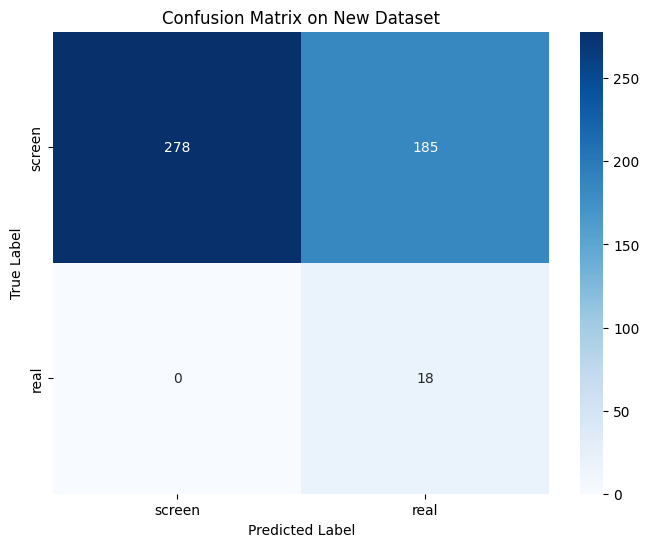

Accuracy on New Dataset: 61.53846153846154
              precision    recall  f1-score   support

      screen       1.00      0.60      0.75       463
        real       0.09      1.00      0.16        18

    accuracy                           0.62       481
   macro avg       0.54      0.80      0.46       481
weighted avg       0.97      0.62      0.73       481



4854

In [5]:
Y_pred_probs = model.predict(X)
Y_pred = (Y_pred_probs > 0.5).astype(int).flatten()

# Confusion Matrix
cm = confusion_matrix(Y, Y_pred)
labels = ['screen', 'real']

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on New Dataset')
plt.show()

# Accuracy and report
print("Accuracy on New Dataset:", accuracy_score(Y, Y_pred) * 100)
print(classification_report(Y, Y_pred, target_names=labels))
del X,Y
gc.collect()

## Generating the Card Liveness Dataset

In [6]:
path_real = "/kaggle/input/all-test-sohaib-bhai-me/Testing/real"
path_fake = "/kaggle/input/all-test-sohaib-bhai-me/Testing/screen3"
X, Y = build_dataset_from_direct_paths(path_real, path_fake)


Final dataset shape: (40, 224, 224, 3) (40,)


## Testing on Card Liveness

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


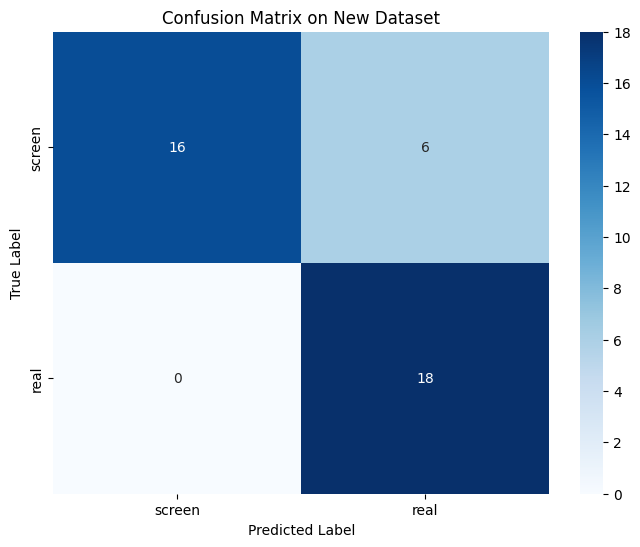

Accuracy on New Dataset: 85.0
              precision    recall  f1-score   support

      screen       1.00      0.73      0.84        22
        real       0.75      1.00      0.86        18

    accuracy                           0.85        40
   macro avg       0.88      0.86      0.85        40
weighted avg       0.89      0.85      0.85        40



5046

In [7]:
Y_pred_probs = model.predict(X)
Y_pred = (Y_pred_probs > 0.5).astype(int).flatten()

# Confusion Matrix
cm = confusion_matrix(Y, Y_pred)
labels = ['screen', 'real']

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on New Dataset')
plt.show()

# Accuracy and report
print("Accuracy on New Dataset:", accuracy_score(Y, Y_pred) * 100)
print(classification_report(Y, Y_pred, target_names=labels))
del X,Y
gc.collect()

## Generating the hand Liveness Dataset

In [8]:
path_real = "/kaggle/input/hand-liveness-dataset-3-classes/Hand Liveness Dataset (3 classes)/real"
path_fake = "/kaggle/input/hand-liveness-dataset-3-classes/Hand Liveness Dataset (3 classes)/screen"
X, Y = build_dataset_from_direct_paths(path_real, path_fake)


Final dataset shape: (11221, 224, 224, 3) (11221,)


## Testing on hand Liveness Dataset

351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step


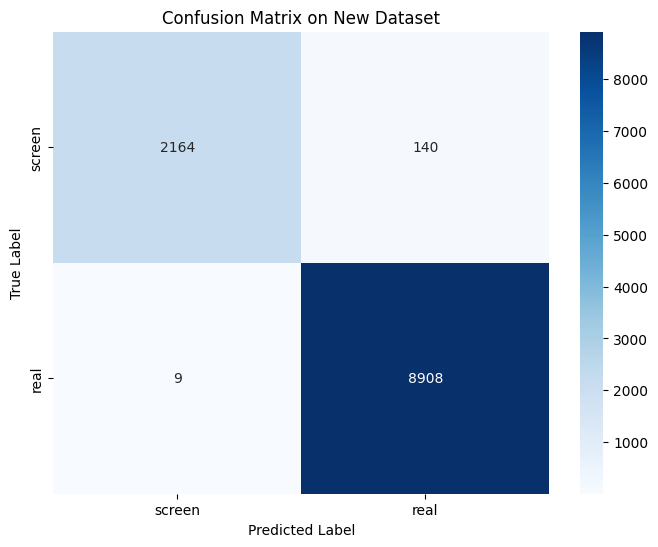

Accuracy on New Dataset: 98.67213260850191
              precision    recall  f1-score   support

      screen       1.00      0.94      0.97      2304
        real       0.98      1.00      0.99      8917

    accuracy                           0.99     11221
   macro avg       0.99      0.97      0.98     11221
weighted avg       0.99      0.99      0.99     11221



4665

In [9]:
Y_pred_probs = model.predict(X)
Y_pred = (Y_pred_probs > 0.5).astype(int).flatten()

# Confusion Matrix
cm = confusion_matrix(Y, Y_pred)
labels = ['screen', 'real']

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on New Dataset')
plt.show()

# Accuracy and report
print("Accuracy on New Dataset:", accuracy_score(Y, Y_pred) * 100)
print(classification_report(Y, Y_pred, target_names=labels))

del X,Y
gc.collect()

In [10]:
def build_dataset_cnn(path, img_size=(224,224)):

    X_real, X_fake = [], []
    folders = sorted(os.listdir(path))

    if len(folders)  > 2 :
        folders.pop(0)

    fake_folders = folders[1]
    real_folder = folders[0]
    

    for folder in folders:
        folder_path = os.path.join(path, folder)
        if not os.path.isdir(folder_path):
            continue

        label = 0 if folder in fake_folders else (1 if folder == real_folder else None)
        if label is None:
            continue

        # 🔶 Limit number of images based on folder type
        files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.tif'))]

        for file in files:
            img_path = os.path.join(folder_path, file)
            I1 = cv2.imread(img_path)
            if I1 is None:
                continue

            I1 = cv2.resize(I1, (224,224))
            I1 = cv2.cvtColor(I1, cv2.COLOR_BGR2RGB)
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
            channels = [clahe.apply(c) for c in cv2.split(I1)]
            I1 = cv2.merge(channels)
            
            # 🔶 Stronger texture enhancement
            channels = cv2.split(I1)
            sharpened_channels = []
            for c in channels:
                for _ in range(3):  # two unsharp passes
                    blur = cv2.GaussianBlur(c, (5,5), 0)
                    c = cv2.addWeighted(c, 2.0, blur, -1.0, 0)
                sharpened_channels.append(c)
            I1 = cv2.merge(sharpened_channels)

            if label == 1:
                X_real.append(I1)
            else:
                X_fake.append(I1)

    X_real = np.array(X_real, dtype='float32')
    X_fake = np.array(X_fake, dtype='float32')

    # 🔶 Augment fake images in batches if needed
    needed = len(X_real) - len(X_fake)
    if needed > 0:
        datagen = ImageDataGenerator(
            rotation_range=15,
            width_shift_range=0.1,
            height_shift_range=0.1,
            zoom_range=0.1,
            horizontal_flip=True
        )
        batch_size = min(needed, 64)
        aug_iter = datagen.flow(X_fake, batch_size=batch_size, shuffle=True)
        augmented_images = []
        generated = 0
        while generated < needed:
            batch = next(aug_iter)
            augmented_images.append(batch)
            generated += batch.shape[0]
        augmented_images = np.concatenate(augmented_images, axis=0)[:needed]
        X_fake = np.concatenate([X_fake, augmented_images], axis=0)

    # 🔶 Create labels
    y_real = np.ones(len(X_real))
    y_fake = np.zeros(len(X_fake))

    # 🔶 Combine and preprocess
    X = np.concatenate([X_real, X_fake], axis=0)
    y = np.concatenate([y_real, y_fake], axis=0)

    print("Dataset shapes:", X.shape, y.shape)

    X = preprocess_input(X)

    return X, y

## Generating the Face Liveness Dataset

In [11]:
X_train,Y_train=build_dataset_cnn(r"/kaggle/input/face-liveness-dataset-3-classes/face liveness dataset v2 nov 2024/face liveness dataset/train")
X_test,Y_test=build_dataset_cnn(r"/kaggle/input/face-liveness-dataset-3-classes/face liveness dataset v2 nov 2024/face liveness dataset/test")
X_val,Y_val=build_dataset_cnn(r"/kaggle/input/face-liveness-dataset-3-classes/face liveness dataset v2 nov 2024/face liveness dataset/val")
X = np.concatenate([X_train, X_test, X_val], axis=0)
Y = np.concatenate([Y_train, Y_test, Y_val], axis=0)
del  X_test, X_val,Y_test, Y_val,X_train,Y_train
gc.collect()

Dataset shapes: (5134, 224, 224, 3) (5134,)
Dataset shapes: (1100, 224, 224, 3) (1100,)
Dataset shapes: (1096, 224, 224, 3) (1096,)


0

## Testing on Face Liveness

230/230 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step


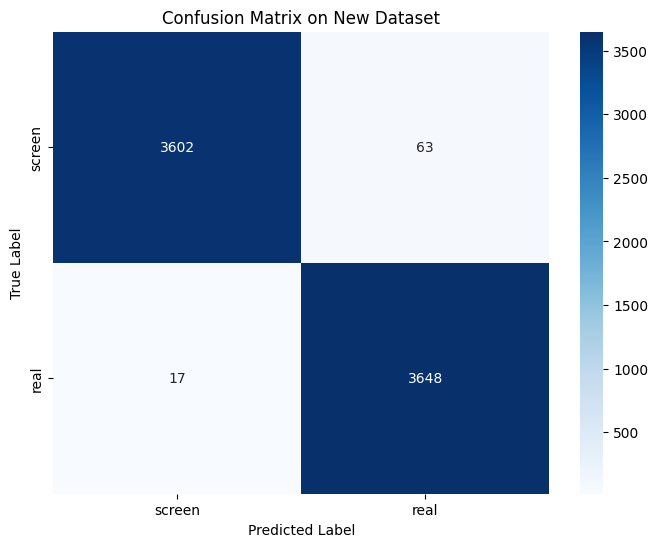

Accuracy on New Dataset: 98.90859481582538
              precision    recall  f1-score   support

      screen       1.00      0.98      0.99      3665
        real       0.98      1.00      0.99      3665

    accuracy                           0.99      7330
   macro avg       0.99      0.99      0.99      7330
weighted avg       0.99      0.99      0.99      7330



4550

In [12]:
Y_pred_probs = model.predict(X)
Y_pred = (Y_pred_probs > 0.5).astype(int).flatten()

# Confusion Matrix
cm = confusion_matrix(Y, Y_pred)
labels = ['screen', 'real']

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on New Dataset')
plt.show()

# Accuracy and report
print("Accuracy on New Dataset:", accuracy_score(Y, Y_pred) * 100)
print(classification_report(Y, Y_pred, target_names=labels))

del X,Y
gc.collect()